# **Project 3 (Final): Analyzing and Predicting Cardiac Events based on ECG data**

**Names**: Joseph Altmann & Kate Meinke

**Course**: DSC 101

**Date**: 5/4/26

Research Goal: Predicting **cardiac events** from Cardiac Recordings

**Abstract**: Our dataset contains long-term ECG recordings from 15 subjects, all with congestive heart failure. Heart failure is becoming significantly more common over time, so being able to predict heart failure patient characteristics from ECG data could be very helpful. The goal of our study is to predict the cardiac event based on the patient's ecg recordings. To do this, we create a logistic regression model, with cardiac event as the target, and ECG recording data. The 4 cardiac events are Normal Beats (N), Ventricular Ectopic Beat (V), and Premature Beats (S and r). The most important to note is the V event as it is critical for assessing the severity of heart failure in these NYHA class 3-4 patients.

**Introduction of Variables:** Our data is the BIDMC Congestive Heart Failure Database which was accessed via PhysioNet. This database includes long-term ecg recordings from 15 subjects. An ECG (electrocardiogram) measures the electrical activity of the heart over time. Of these subjects, 11 were men (ages 22-71) and 4 were women (aged 54-63). All of the patients fell within the NYHA class 3-4 indicating severe heart failure that limits physical activity. This group was also part of a larger study that recieved conventional medical therapy before receiving another agent. Each recording is about 20 hours long and contains two ECG signals that are sampled at 250 samples per second (see below about subsampling) over a range of + or - 10 millivolts.

**Citation:** Goldberger, A., Amaral, L., Glass, L., Hausdorff, J., Ivanov, P. C., Mark, R., ... & Stanley, H. E. (2000). PhysioBank, PhysioToolkit, and PhysioNet: Components of a new research resource for complex physiologic signals. Circulation [Online]. 101 (23), pp. e215–e220. RRID:SCR_007345.

In [145]:
# @title
!pip install wfdb

In [146]:
import wfdb
import os
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [147]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [148]:
# # path for kate
data_path = '/content/drive/MyDrive/files/'

# path for Binod
#data_path = '/content/drive/MyDrive/BIDMC/'

In [149]:
items = os.listdir(data_path)
print(items)

['chf01.dat', 'chf02.dat', 'chf03.dat', 'chf04.ecg-', 'chf04.dat', 'chf05.dat', 'chf06.dat', 'chf07.dat', 'chf08.dat', 'chf09.dat', 'chf10.dat', 'chf11.dat', 'chf12.dat', 'chf13.dat', 'chf14.dat', 'chf15.dat', 'chf01.ecg', 'chf02.ecg-', 'chf03.ecg', 'chf05.ecg', 'chf06.ecg', 'chf07.ecg', 'chf08.ecg', 'chf09.ecg', 'chf10.ecg', 'chf11.ecg', 'chf12.ecg', 'chf13.ecg', 'chf14.ecg', 'chf15.ecg', 'RECORDS', 'ANNOTATORS', 'chf15.hea-', 'chf14.hea-', 'chf13.hea-', 'chf12.hea-', 'chf11.hea-', 'chf10.hea-', 'chf09.hea-', 'chf08.hea-', 'chf07.hea-', 'chf06.hea-', 'chf05.hea-', 'chf04.hea-', 'chf03.hea-', 'chf02.hea-', 'chf01.hea-', 'chf04.ecg', 'chf02.ecg', 'chf15.hea', 'chf14.hea', 'chf13.hea', 'chf12.hea', 'chf11.hea', 'chf10.hea', 'chf09.hea', 'chf08.hea', 'chf07.hea', 'chf06.hea', 'chf05.hea', 'chf04.hea', 'chf03.hea', 'chf02.hea', 'chf01.hea', 'SHA256SUMS.txt', 'Project_3.ipynb']


 **Subsampling:** In the code below, we read the data, isolate the fields and signals, and subsample it. The data is sampled every .004 seconds for 20 hours, which needed to be subsampled. This displays the data by minute, taking the first recording of each 60 second interval. Additionally, we index by time so that our dataframe is consistent with each recording taken by the minute along with its corresponding data.


In [150]:
def get_subsampled_subject_data(subject_id):
    """
    Reads ECG data for a subject and returns a DataFrame
    subsampled to one sample per minute.
    """
    try:
        # Load the signals and metadata
        # Each record contains two ECG signals [1]
        full_path = os.path.join(data_path, subject_id)
        # record = wfdb.rdrecord(full_path)
        signals, fields = wfdb.rdsamp(full_path)

        # The sampling rate is 250 samples per second [1]
        fs = fields['fs']
        samples_per_minute = int(fs * 60) # 15,000 samples

        # Subsample the data (taking the first sample of every minute)
        subsampled_signal = signals[::samples_per_minute]

        # Create a time index representing elapsed minutes
        time_index = np.arange(len(subsampled_signal))

        # Create the DataFrame
        df = pd.DataFrame(
            subsampled_signal,
            columns=['ecg1', 'ecg2'],
            index=time_index
        )
        df.index.name = 'time_minutes'

        return df

    except FileNotFoundError:
        print(f"Error: Files for {subject_id} not found.")
        return None

In [151]:
ecg1 = get_subsampled_subject_data('chf01')


In [152]:
ecg1.shape

(1200, 2)

In [153]:
ecg1.head()

,ecg1,ecg2
time_minutes,,
0,0.635,-0.640
1,-0.370,-0.510
2,-0.430,0.000
3,-0.415,0.070
4,-0.360,-0.265


**Creating the DataFrame:** Now, we must add the annotations that display the patient details (cardiac event). To do this, we load the annotations and create a DataFrame of all of the ecg recordings and then again divide into recordings taken once per minute. Then, we again use time as the index to organize the recordings and assign the cardiac event to their respective patient's ecg values.

In [154]:
def get_subsampled_ecg_annotations(subject_id):
    """
    Reads the .ecg annotation file and returns a DataFrame
    containing only the first detected heartbeat of every minute.
    """
    record_path = os.path.join(data_path, subject_id)

    try:
        # Load the automated annotations [1]
        annotations = wfdb.rdann(record_path, extension='ecg')

        # The database sampling frequency is 250 Hz [1]
        fs = 250
        samples_per_minute = fs * 60 # 15,000 samples

        # Create a full DataFrame of all detected heartbeats
        df_all_beats = pd.DataFrame({
            'sample_index': annotations.sample,
            'cardiac_event': annotations.symbol,
            'time_seconds': annotations.sample / fs
        })

        # Calculate which minute each beat belongs to
        # (e.g., samples 0-14999 are Minute 0, 15000-29999 are Minute 1)
        df_all_beats['time_minutes'] = df_all_beats['sample_index'] // samples_per_minute

        # Subsample: Keep only the first heartbeat that appears in each minute
        df_subsampled = df_all_beats.drop_duplicates(subset='time_minutes', keep='first')

        # Set the time_minutes as the index to match your signal DataFrame
        df_subsampled.set_index('time_minutes', inplace=True)

        return df_subsampled

    except FileNotFoundError:
        print(f"Error: Annotation file for {subject_id} not found.")
        return None

In [155]:
cardiac_event_1  = get_subsampled_ecg_annotations('chf01')

In [156]:
cardiac_event_1.shape

(1200, 3)

In [157]:
cardiac_event_1.head()


,sample_index,cardiac_event,time_seconds
time_minutes,,,
0,28,N,0.112
1,15048,N,60.192
2,30194,N,120.776
3,45194,N,180.776
4,60031,N,240.124


In [158]:
cardiac_event_1['cardiac_event'].unique()

<ArrowStringArray>
['N', 'S', 'r', 'V']
Length: 4, dtype: str

### **merging ecg1 and cardiac_event_1 data on index**

In [159]:
sub1 = ecg1.merge(cardiac_event_1['cardiac_event'],
                  left_index=True,
                  right_index=True)

In [160]:
sub1.head()

,ecg1,ecg2,cardiac_event
time_minutes,,,
0,0.635,-0.640,N
1,-0.370,-0.510,N
2,-0.430,0.000,N
3,-0.415,0.070,N
4,-0.360,-0.265,N


In [161]:
sub1['cardiac_event'].value_counts()


cardiac_event
N    1192
S       4
V       3
r       1
Name: count, dtype: int64

 **Combining all patients:** Here, we repeat the process to create a df for each patient and combine them into a single dataframe.

In [162]:
all_subject_data = []

for i in range(1, 16):
    subject_id = f'chf{i:02d}'

    # 1. Get the signal data
    df_signal = get_subsampled_subject_data(subject_id)

    # 2. Get the annotation data
    df_ann = get_subsampled_ecg_annotations(subject_id)

    if df_signal is not None and df_ann is not None:
        # 3. Join them on the 'time_minutes' index
        # This aligns the signal at the start of the minute with the first beat of that minute
        df_combined = df_signal.join(df_ann[['cardiac_event']], how='left')



        # 4. Add the Subject_ID
        df_combined['Subject_ID'] = subject_id

        all_subject_data.append(df_combined)



final_df = pd.concat(all_subject_data).reset_index()

In [163]:
final_df.head()

,time_minutes,ecg1,ecg2,cardiac_event,Subject_ID
0,0,0.635,-0.640,N,chf01
1,1,-0.370,-0.510,N,chf01
2,2,-0.430,0.000,N,chf01
3,3,-0.415,0.070,N,chf01
4,4,-0.360,-0.265,N,chf01


In [164]:
final_df # each patient has minutes 1-1199 along with the cardiac event

,time_minutes,ecg1,ecg2,cardiac_event,Subject_ID
0,0,0.635,-0.640,N,chf01
1,1,-0.370,-0.510,N,chf01
2,2,-0.430,0.000,N,chf01
3,3,-0.415,0.070,N,chf01
4,4,-0.360,-0.265,N,chf01
...,...,...,...,...,...
17932,1195,-0.525,1.115,N,chf15
17933,1196,-0.730,0.590,N,chf15
17934,1197,-0.540,0.805,N,chf15
17935,1198,-0.800,0.650,N,chf15


**Displaying Patient Information:** In this code chunk, we are reading the header (hea) files that store information about the patient: age, gender, and NYHA class(severity of heart failure). We do this by matching the patient to their data. This will aid in visualizing data by providing information about the patient that can help suggest indicators or trends in heart failure.

In [165]:
def get_subject_metadata():
    """
    Corrected function to read header files and extract clinical metadata
    using regular expressions to avoid KeyErrors.
    """
    metadata_list = []
    subjects = [f'chf{i:02d}' for i in range(1, 16)]

    for subject in subjects:
        record_path = os.path.join(data_path, subject)
        try:
            # rdheader reads the .hea file
            header = wfdb.rdheader(record_path)

            # Combine all comments into a single string for easier searching
            full_comment_text = " ".join(header.comments)

            # Use regex to find the values (handles cases where they are on the same line)
            age_match = re.search(r'Age:\s*(\d+)', full_comment_text)
            sex_match = re.search(r'Sex:\s*([MF])', full_comment_text)
            nyha_match = re.search(r'NYHA class:\s*([I|V|-]+)', full_comment_text)

            # Build the dictionary, providing None if a value isn't found
            subject_info = {
                'subject': subject,
                'Age': age_match.group(1) if age_match else None,
                'Sex': sex_match.group(1) if sex_match else None,
                'NYHA class': nyha_match.group(1) if nyha_match else None
            }

            metadata_list.append(subject_info)

        except FileNotFoundError:
            print(f"Warning: Header for {subject} not found.")
            # Even if the file is missing, we add a row with Nones to keep the index consistent
            metadata_list.append({'subject': subject, 'Age': None, 'Sex': None, 'NYHA class': None})

    # Create the DataFrame
    df_metadata = pd.DataFrame(metadata_list)

    # Reorder columns safely
    return df_metadata[['subject', 'Age', 'Sex', 'NYHA class']]

In [166]:
subject_info_df = get_subject_metadata()

In [167]:
subject_info_df

,subject,Age,Sex,NYHA class
0,chf01,71,M,III-IV
1,chf02,61,F,III-IV
2,chf03,63,M,III-IV
3,chf04,54,M,III-IV
4,chf05,59,F,III-IV
5,chf06,NaN,M,III-IV
6,chf07,48,M,III-IV
7,chf08,51,M,III-IV
8,chf09,63,F,III-IV
9,chf10,22,M,III-IV


**Visualization**: In these two graphs, we are taking the 3 oldest and 3 youngest patients and comparing their ecg data over the 20 hour recordings. As seen in the visualizations, the older patients experience more variation in their values. This suggests more volatility in older patients, whereas the younger patients seem to have more stability in their trends with clear spikes. We can then compare this with when they experienced a cardiac event.

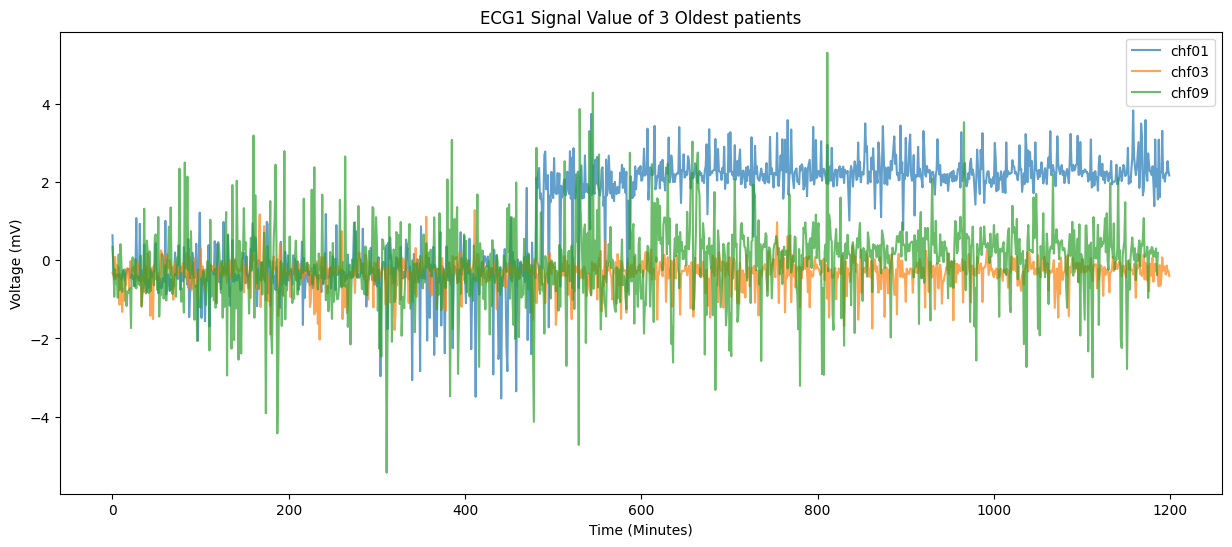

In [168]:
# Plot the 3 oldest subjects to compare their minute-by-minute trends
plt.figure(figsize=(15, 6))
for subject in ['chf01', 'chf03', 'chf09']:
    subset = final_df[final_df['Subject_ID'] == subject]
    plt.plot(subset['time_minutes'], subset['ecg1'], label=subject, alpha=0.7)

plt.title("ECG1 Signal Value of 3 Oldest patients")
plt.xlabel("Time (Minutes)")
plt.ylabel("Voltage (mV)")
plt.legend()
plt.show()

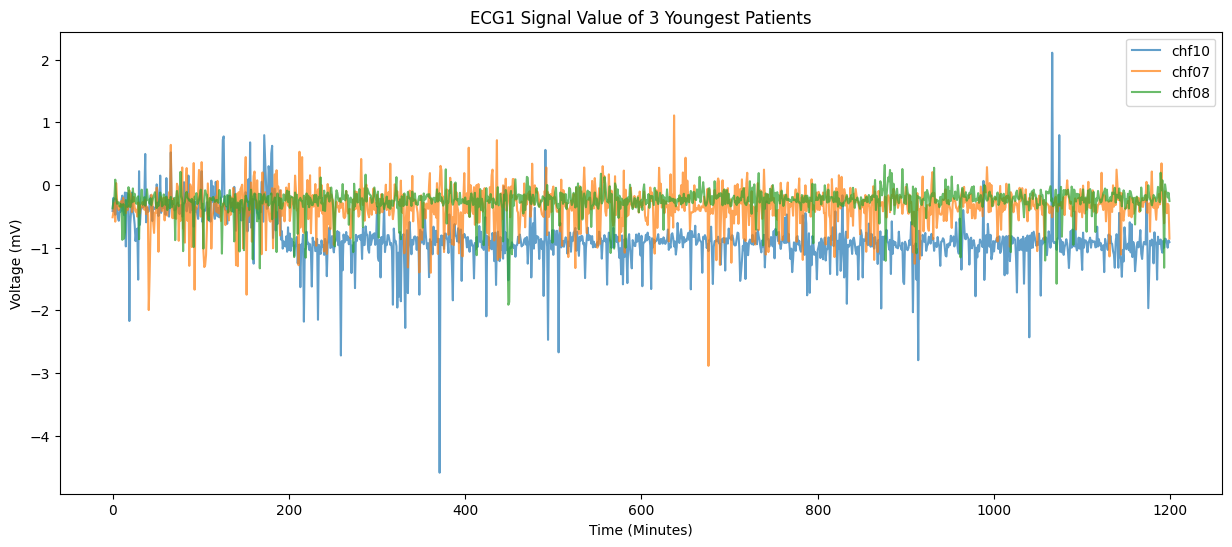

In [169]:
# Plot the 3 youngest subjects to compare their minute-by-minute trends
plt.figure(figsize=(15, 6))
for subject in ['chf10', 'chf07', 'chf08']:
    subset = final_df[final_df['Subject_ID'] == subject]
    plt.plot(subset['time_minutes'], subset['ecg1'], label=subject, alpha=0.7)

plt.title("ECG1 Signal Value of 3 Youngest Patients")
plt.xlabel("Time (Minutes)")
plt.ylabel("Voltage (mV)")
plt.legend()
plt.show()

**Cardiac Event Count:** Here we visualize the number of cardiac events per patient. We can see that the patients all face very few cardiac events, meaning it might be difficult to asses the predictive abilities of our machine learning models later on, because there is an overwhelming amount of normal activtity that could mask the small number of abnormal acivity.

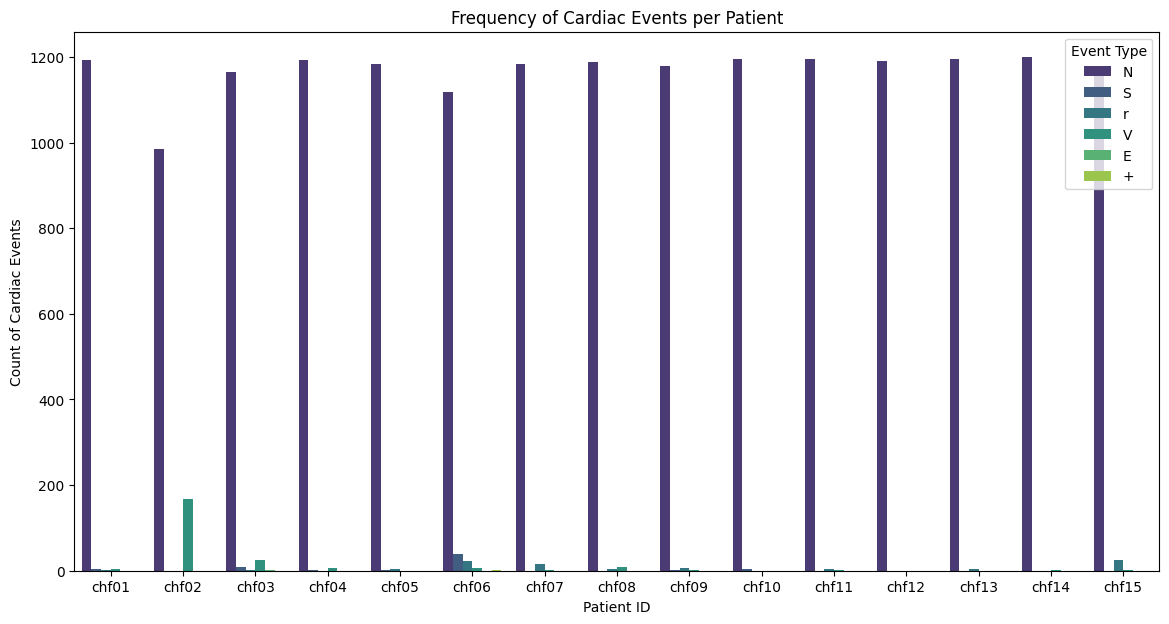

In [170]:
plt.figure(figsize=(14, 7))

sns.countplot(data= final_df, x='Subject_ID', hue='cardiac_event', palette='viridis')

plt.title('Frequency of Cardiac Events per Patient')
plt.xlabel('Patient ID')
plt.ylabel('Count of Cardiac Events')
plt.legend(title='Event Type', loc='upper right')


plt.show()

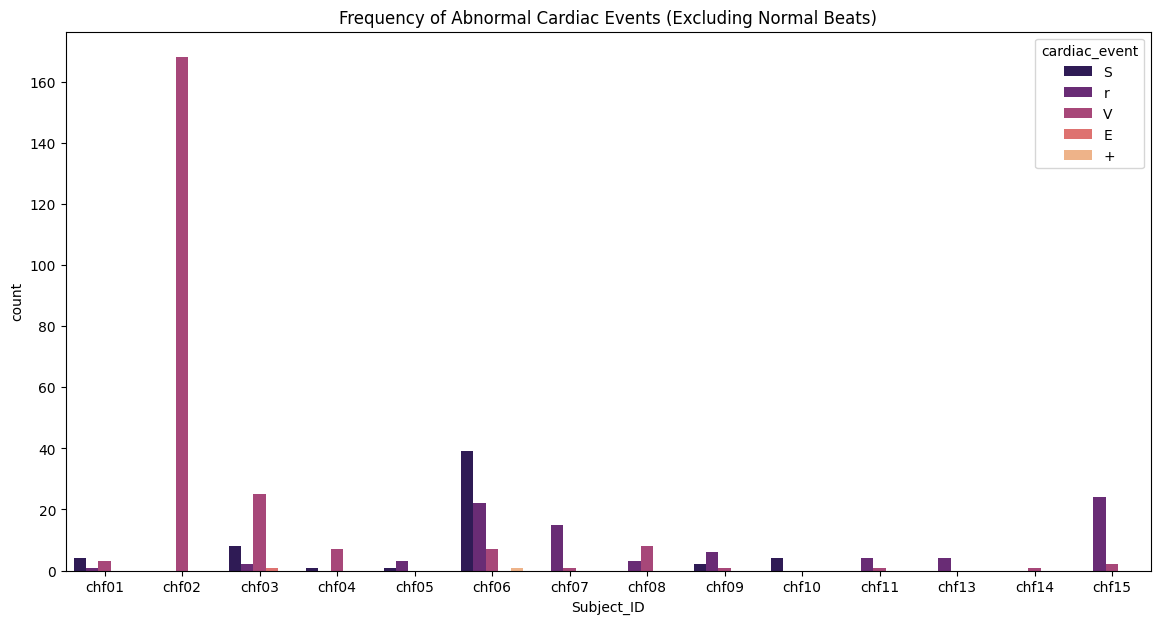

In [171]:
# without normal beats
arrhythmia_df = final_df[final_df['cardiac_event'] != 'N']

plt.figure(figsize=(14, 7))
sns.countplot(data=arrhythmia_df, x='Subject_ID', hue='cardiac_event', palette='magma')
plt.title('Frequency of Abnormal Cardiac Events (Excluding Normal Beats)')
plt.show()

**Logistic Regression**:

In [172]:
log_model_df = final_df.dropna()
X = final_df.drop(columns = ['time_minutes', 'cardiac_event', 'Subject_ID'])
y = final_df['cardiac_event'].factorize()[0]

In [173]:
# 1. Identify your features
features = ['ecg1', 'ecg2']

# 2. Create a clean version of your dataframe
# This removes any row where ecg1 or ecg2 is missing
clean_df = final_df.dropna(subset=features + ['cardiac_event'])

X = clean_df[features]
y = clean_df['cardiac_event'].factorize()[0]

In [174]:
from sklearn.model_selection import train_test_split

In [175]:
X_train, X_test, y_train, y_test, = train_test_split(X, y, test_size = 0.1)

In [176]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((16112, 2), (1791, 2), (16112,), (1791,))

In [177]:
from sklearn.preprocessing import StandardScaler

In [178]:
# Data Normalization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [179]:
#Building Model
from sklearn.linear_model import LogisticRegression

In [180]:
#create instance
log_reg_model = LogisticRegression()

In [181]:
log_reg_model.fit(X_train_scaled, y_train)

LogisticRegression()

In [182]:
weights = log_reg_model.coef_
intercept = log_reg_model.intercept_

In [183]:
weights.ravel(), intercept

(array([ 0.02918017, -0.20336323,  0.07633486, -0.20661066, -0.00214964,
         0.09845163, -0.02775592, -0.12622607, -0.07560947,  0.43774833]),
 array([ 5.16866482, -0.47253215, -0.17152225,  0.75774505, -5.28235547]))

In [184]:
X.columns.values

<ArrowStringArray>
['ecg1', 'ecg2']
Length: 2, dtype: str

In [185]:
weights = log_reg_model.coef_

coef_df = pd.DataFrame({
    'Feature': X.columns,     # This gets ['ecg1', 'ecg2']
    'Weight': weights[0],     # Use [0] because coef_ is a 2D array
    'Odds': np.exp(weights[0])
})

# Sort them to see which feature is the most 'dangerous' indicator of an event
print(coef_df.sort_values(by='Weight', ascending=False))

  Feature    Weight      Odds
0    ecg1  0.029180  1.029610
1    ecg2 -0.203363  0.815982


In [186]:
y_test_pred = log_reg_model.predict(X_test_scaled)

In [187]:
y_test_pred

array([0, 0, 0, ..., 0, 0, 0])

In [188]:
y_test

array([0, 0, 0, ..., 0, 0, 0])

In [189]:
#Model Performance Evaluation

In [190]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report)

In [191]:
accuracy = accuracy_score(y_test, y_test_pred)
accuracy

0.9765494137353434

In [192]:
precision = precision_score(y_test, y_test_pred, average='weighted')
precision

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


0.9536487574668429

In [193]:
recall = recall_score(y_test, y_test_pred, average='weighted')
recall

0.9765494137353434

In [194]:
f1 = f1_score(y_test, y_test_pred, average='weighted')
f1

0.9649632342503477

In [195]:
cm = confusion_matrix(y_test, y_test_pred)
cm
# no error

array([[1749,    0,    0,    0,    0],
       [   3,    0,    0,    0,    0],
       [   6,    0,    0,    0,    0],
       [  32,    0,    0,    0,    0],
       [   1,    0,    0,    0,    0]])

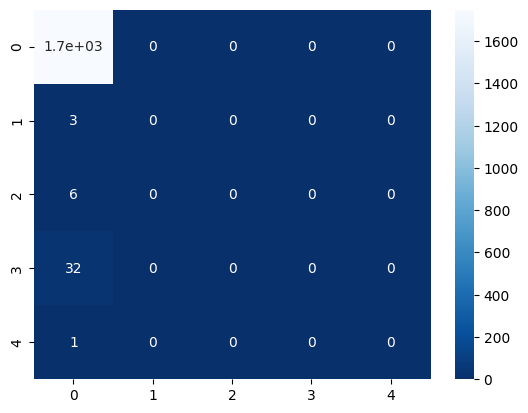

In [196]:
sns.heatmap(cm, annot=True, cmap ='Blues_r')
plt.show()

In [197]:
classification = classification_report(y_test, y_test_pred)
print(classification)

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1749
           1       0.00      0.00      0.00         3
           2       0.00      0.00      0.00         6
           3       0.00      0.00      0.00        32
           5       0.00      0.00      0.00         1

    accuracy                           0.98      1791
   macro avg       0.20      0.20      0.20      1791
weighted avg       0.95      0.98      0.96      1791



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Summary of Findings:**

Our study aimed to predict cardiac events from ECG recordings of 15 heart failure patients. After subsampling the data to one reading per minute, we were able to use it to achieve our goal. We found that older patients displayed much greater ECG volitility than younger patients. Also, abnormal cardiac events are very rare compared to normal heart beats. We created a logistic regression model in order to predict cardiac events purely from the ECG recordings of each patient. Our model achieved 97.9% accuracy, however it was much better at predicting normal beats than abnormal cardiac events. This is likely due to how much more common normal beats are, making the abnormal ones very difficult to predict. The macro average f1 score is a 0.25, which reflects the model's true performance.